# CIFAR-10 Accuracy Comparison: CNN vs GCNN (p4) vs GCNN (p4m)

This notebook replicates the core experiment from:
> Cohen & Welling (2016). *Group Equivariant Convolutional Networks*. ICML 2016.

**Goal:** Train three models on CIFAR-10 with an approximately equal parameter budget and compare test accuracy.

| Model | Symmetry Group | Expected Benefit |
|-------|---------------|------------------|
| `CNN` | Z² (translations only) | Baseline |
| `GCNN-p4` | p4 (translations + 90° rotations) | ~4× weight sharing over CNN |
| `GCNN-p4m` | p4m (translations + rotations + reflections) | ~8× weight sharing over CNN |

The p4 and p4m models use **fewer filters** to keep parameters comparable to the CNN, but their G-convolutions exploit symmetry to boost representational capacity without extra parameters.

---
**Folder layout expected** (same as `filter_heatmaps.ipynb`):
```
experiment/
├── cifar10_gcnn_experiment.ipynb   ← this file
├── cnngeneral.py
├── gcnngeneral.py
└── gcnn_p4mgeneral.py
```
Trained checkpoints (`.pth`) will be saved here automatically.

## 1. Environment Setup

In [1]:
import subprocess
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

print(f'Running in Colab: {IN_COLAB}')

Running in Colab: True


In [2]:
# ── Install / reconcile dependencies ──────────────────────────────────────
# IMPORTANT: This cell must be run TWICE on first use.
#
# Why: escnn installs a numpy version whose compiled C extensions are
# incompatible with the numpy already loaded in the kernel. The only safe
# fix is to (1) install everything, (2) restart the kernel so Python loads
# a single consistent numpy from scratch, then (3) continue normally.
#
# Run 1 → installs packages + restarts kernel automatically.
# Run 2 → all imports succeed, prints 'Environment OK'.

import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args], check=True)

# Step 1: install all packages via pip (no imports yet — numpy not touched)
pip('escnn', 'matplotlib', 'seaborn', 'numpy>=1.24,<2.0')
print('All packages installed/updated.')

# Step 2: verify in a clean subprocess (no stale in-process state)
check = subprocess.run(
    [sys.executable, '-c',
     'import numpy as np; np.random.RandomState(); print(np.__version__)'],
    capture_output=True, text=True
)

if check.returncode == 0:
    # Check if the *running* kernel also has the compatible numpy in memory
    try:
        import numpy as _np
        _np.random.RandomState()          # raises ValueError if stale
        import escnn, matplotlib, seaborn
        print(f'Environment OK — numpy {_np.__version__}, escnn {escnn.__version__}')
    except (ValueError, ImportError):
        print('Kernel has stale numpy in memory — restarting now.')
        print('>>> Re-run this cell once more after the kernel restarts. <<<')
        try:
            import IPython
            IPython.get_ipython().kernel.do_shutdown(restart=True)
        except Exception:
            import os, signal
            os.kill(os.getpid(), signal.SIGTERM)
else:
    print('numpy install issue:')
    print(check.stderr[-500:])


All packages installed/updated.
Environment OK — numpy 1.26.4, escnn 1.0.11


In [3]:
if IN_COLAB:
    from google.colab import files
    print('Upload cnngeneral.py, gcnngeneral.py, gcnn_p4mgeneral.py')
    uploaded = files.upload()
    print(f'Uploaded: {list(uploaded.keys())}')
else:
    print('Local run — skipping Colab upload cell.')

Upload cnngeneral.py, gcnngeneral.py, gcnn_p4mgeneral.py


Saving cnngeneral.py to cnngeneral (1).py
Saving gcnn_p4mgeneral.py to gcnn_p4mgeneral (1).py
Saving gcnngeneral.py to gcnngeneral (1).py
Uploaded: ['cnngeneral (1).py', 'gcnn_p4mgeneral (1).py', 'gcnngeneral (1).py']


In [4]:
import math
import time
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
Using device    : cuda


## 2. Experiment Configuration

Edit the cell below to control training. Defaults are set for a **quick smoke-test** (`NUM_EPOCHS = 30`). For a paper-quality run, set `NUM_EPOCHS = 300`.

In [5]:
# ── Training hyper-parameters ──────────────────────────────────────────────
NUM_EPOCHS      = 30        # 30 for quick test, 300 for paper-quality
BATCH_SIZE      = 128
LEARNING_RATE   = 0.05
MOMENTUM        = 0.9
WEIGHT_DECAY    = 1e-4

# LR schedule: divide by 10 at these epoch boundaries
LR_MILESTONES   = [int(NUM_EPOCHS * 0.50),
                   int(NUM_EPOCHS * 0.75)]
LR_GAMMA        = 0.1

# ── Data augmentation ──────────────────────────────────────────────────────
USE_AUGMENTATION = True     # horizontal flips + small crops (CIFAR10+)

# ── Which models to train ─────────────────────────────────────────────────
MODELS_TO_TRAIN = ['cnn', 'gcnn_p4', 'gcnn_p4m']   # comment out any you want to skip

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42

# ── Paths ─────────────────────────────────────────────────────────────────
EXPERIMENT_DIR = Path('.').resolve()
RESULTS_FILE   = EXPERIMENT_DIR / 'results.json'

# ── Display names ─────────────────────────────────────────────────────────
DISPLAY_NAMES = {
    'cnn'      : 'CNN (Z\u00b2)',
    'gcnn_p4'  : 'GCNN (p4)',
    'gcnn_p4m' : 'GCNN (p4m)',
}
COLORS = {
    'cnn'      : '#5470c6',
    'gcnn_p4'  : '#91cc75',
    'gcnn_p4m' : '#ee6666',
}

# ── Checkpoint / skip controls ────────────────────────────────────────────
# Set FORCE_RETRAIN = True to retrain a model even if its .pth already exists.
FORCE_RETRAIN = False

# ── Pre-existing results you already have ────────────────────────────────
# If you have best_test_acc values from a previous run (but no results.json),
# paste them here so the summary/plots work without retraining.
# Set to None for any model you don't have results for yet.
KNOWN_RESULTS = {
    'cnn'      : None,   # e.g. 78.50  ← paste your CNN best acc here if you have it
    'gcnn_p4'  : None,   # e.g. 80.12  ← paste your GCNN-p4 best acc here
    'gcnn_p4m' : None,   # e.g. 81.44  ← paste your GCNN-p4m best acc here
}

print('Configuration loaded.')
print(f'  Epochs         : {NUM_EPOCHS}')
print(f'  Augmentation   : {USE_AUGMENTATION}')
print(f'  LR milestones  : {LR_MILESTONES}')
print(f'  Models         : {MODELS_TO_TRAIN}')
print(f'  Experiment dir : {EXPERIMENT_DIR}')
print(f'  Force retrain  : {FORCE_RETRAIN}')


Configuration loaded.
  Epochs         : 30
  Augmentation   : True
  LR milestones  : [15, 22]
  Models         : ['cnn', 'gcnn_p4', 'gcnn_p4m']
  Experiment dir : /content


## 3. Reproducibility & Path Setup

In [6]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Add experiment dir to path so model definition files are importable
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

print(f'Seed set to {SEED}')
print(f'sys.path[0] = {sys.path[0]}')

Seed set to 42
sys.path[0] = /content


## 4. CIFAR-10 Data Loaders

In [7]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
else:
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

DATA_ROOT = EXPERIMENT_DIR / 'data'
trainset  = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=train_transform)
testset   = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=test_transform)

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(trainset)}')
print(f'Test samples  : {len(testset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Augmentation  : {USE_AUGMENTATION}')

100%|██████████| 170M/170M [00:05<00:00, 30.7MB/s]


Train samples : 50000
Test samples  : 10000
Train batches : 391
Augmentation  : True


## 5. Model Instantiation

Models are loaded from the definition files in the same folder. The import functions below fall back gracefully if a file is missing.

In [8]:
def import_cnn():
    from cnngeneral import Net
    return Net

def import_gcnn_p4():
    from gcnngeneral import GCNN
    return GCNN

def import_gcnn_p4m():
    from gcnn_p4mgeneral import GCNNP4M
    return GCNNP4M

def build_model(model_key: str) -> nn.Module:
    """Instantiate a fresh (untrained) model."""
    if model_key == 'cnn':
        return import_cnn()()
    elif model_key == 'gcnn_p4':
        return import_gcnn_p4()()
    elif model_key == 'gcnn_p4m':
        return import_gcnn_p4m()()
    else:
        raise ValueError(f'Unknown model key: {model_key}')

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick check: instantiate each model and report parameter counts
print('Model parameter counts:')
print(f'{"Model":<20} {"Parameters":>12}')
print('-' * 34)
for key in MODELS_TO_TRAIN:
    try:
        m = build_model(key)
        n = count_parameters(m)
        print(f'{DISPLAY_NAMES[key]:<20} {n:>12,}')
        del m
    except (ModuleNotFoundError, ImportError) as e:
        print(f'{DISPLAY_NAMES[key]:<20}   [MISSING: {e}]')

Model parameter counts:
Model                  Parameters
----------------------------------
CNN (Z²)                1,372,254
GCNN (p4)                 926,304
GCNN (p4m)                824,896


## 6. Training Loop

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)
    return total_loss / total, 100.0 * correct / total


def train_model(model_key: str, device, num_epochs: int):
    """
    Full training run for one model.
    Returns a history dict with keys: train_loss, train_acc, test_loss, test_acc.
    Best checkpoint is saved to <model_key>.pth.
    """
    print(f'\n{"="*60}')
    print(f'  Training {DISPLAY_NAMES[model_key]}')
    print(f'{"="*60}')

    set_seed(SEED)   # reset seed for each model for fair comparison
    model = build_model(model_key).to(device)
    n_params = count_parameters(model)
    print(f'  Parameters: {n_params:,}')

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),
                          lr=LEARNING_RATE,
                          momentum=MOMENTUM,
                          weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                                milestones=LR_MILESTONES,
                                                gamma=LR_GAMMA)

    history = {'train_loss': [], 'train_acc': [],
               'test_loss':  [], 'test_acc':  []}
    best_acc  = 0.0
    ckpt_path = EXPERIMENT_DIR / f'{model_key}.pth'

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        # Save best checkpoint
        if te_acc > best_acc:
            best_acc = te_acc
            torch.save(model.state_dict(), ckpt_path)

        if epoch == 1 or epoch % 5 == 0 or epoch == num_epochs:
            elapsed = time.time() - t0
            print(f'  Epoch [{epoch:>3}/{num_epochs}] '
                  f'train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% '
                  f'test_loss={te_loss:.4f} test_acc={te_acc:.2f}% '
                  f'(best={best_acc:.2f}%)  [{elapsed:.0f}s]')

    print(f'  → Best test accuracy: {best_acc:.2f}%  |  Checkpoint: {ckpt_path}')
    history['best_test_acc'] = best_acc
    history['n_params']      = n_params
    return history

print('Training functions defined.')

Training functions defined.


## 7. Run Training

This cell trains all models sequentially. Results are saved to `results.json` so you can re-run the plotting cells without retraining.

In [10]:
# ── Run Training (checkpoint-aware) ──────────────────────────────────────
#
# Logic per model:
#   1. results.json already has this model  → load from file, skip training
#   2. .pth exists + FORCE_RETRAIN=False    → evaluate checkpoint to get
#      best_test_acc, build a minimal history, skip full training
#   3. KNOWN_RESULTS has a value for this model (no .pth needed)
#      → use that best_test_acc directly, skip training
#   4. Otherwise                            → train from scratch as normal
#
# After the loop, results.json is written/updated so future runs hit case 1.

all_results = {}

# Pre-load results.json if it exists
_saved = {}
if RESULTS_FILE.exists():
    with open(RESULTS_FILE) as _f:
        _saved = json.load(_f)

for model_key in MODELS_TO_TRAIN:
    ckpt_path = EXPERIMENT_DIR / f'{model_key}.pth'

    # ── Case 1: already in results.json ──────────────────────────────────
    if not FORCE_RETRAIN and model_key in _saved:
        print(f'[SKIP]  {DISPLAY_NAMES[model_key]} — loaded from results.json '
              f'(best acc = {_saved[model_key]["best_test_acc"]:.2f}%)')
        all_results[model_key] = _saved[model_key]
        continue

    # ── Case 2: .pth exists — evaluate to get accuracy, skip training ────
    if not FORCE_RETRAIN and ckpt_path.exists():
        print(f'[EVAL]  {DISPLAY_NAMES[model_key]} — checkpoint found, evaluating…')
        try:
            model = build_model(model_key).to(DEVICE)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            criterion = nn.CrossEntropyLoss()
            te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)
            n_params = count_parameters(model)
            del model
            # Build a minimal history (single-point — no epoch curves)
            history = {
                'train_loss'    : [],
                'train_acc'     : [],
                'test_loss'     : [te_loss],
                'test_acc'      : [te_acc],
                'best_test_acc' : te_acc,
                'n_params'      : n_params,
                'from_checkpoint': True,
            }
            print(f'        → Test accuracy from checkpoint: {te_acc:.2f}%')
            all_results[model_key] = history
            continue
        except Exception as e:
            print(f'        Checkpoint eval failed ({e}), falling through to training.')

    # ── Case 3: known result provided, but no .pth / results.json ────────
    known_acc = KNOWN_RESULTS.get(model_key)
    if not FORCE_RETRAIN and known_acc is not None:
        print(f'[KNOWN] {DISPLAY_NAMES[model_key]} — using provided best_test_acc = {known_acc:.2f}%')
        try:
            m = build_model(model_key)
            n_params = count_parameters(m)
            del m
        except Exception:
            n_params = 0
        history = {
            'train_loss'    : [],
            'train_acc'     : [],
            'test_loss'     : [],
            'test_acc'      : [],
            'best_test_acc' : float(known_acc),
            'n_params'      : n_params,
            'from_known'    : True,
        }
        all_results[model_key] = history
        continue

    # ── Case 4: train from scratch ────────────────────────────────────────
    try:
        history = train_model(model_key, DEVICE, NUM_EPOCHS)
        all_results[model_key] = history
    except (ModuleNotFoundError, ImportError) as e:
        print(f'\nSkipping {model_key}: model definition file not found ({e})')
    except Exception as e:
        print(f'\nError training {model_key}: {e}')
        raise

# Persist updated results (merge with any pre-existing saved results)
_saved.update(all_results)
with open(RESULTS_FILE, 'w') as f:
    json.dump(_saved, f, indent=2)
print(f'\nResults saved to {RESULTS_FILE}')



  Training CNN (Z²)
  Parameters: 1,372,254
  Epoch [  1/30] train_loss=1.4896 train_acc=47.01% test_loss=1.2945 test_acc=54.96% (best=54.96%)  [26s]
  Epoch [  5/30] train_loss=0.5768 train_acc=80.38% test_loss=0.8155 test_acc=73.10% (best=75.56%)  [137s]
  Epoch [ 10/30] train_loss=0.3707 train_acc=87.44% test_loss=0.4930 test_acc=83.58% (best=83.83%)  [278s]
  Epoch [ 15/30] train_loss=0.2701 train_acc=90.90% test_loss=0.3638 test_acc=87.80% (best=87.80%)  [416s]
  Epoch [ 20/30] train_loss=0.1363 train_acc=95.81% test_loss=0.2675 test_acc=91.30% (best=91.30%)  [555s]
  Epoch [ 25/30] train_loss=0.1159 train_acc=96.61% test_loss=0.2622 test_acc=91.30% (best=91.30%)  [694s]
  Epoch [ 30/30] train_loss=0.1113 train_acc=96.80% test_loss=0.2597 test_acc=91.39% (best=91.44%)  [832s]
  → Best test accuracy: 91.44%  |  Checkpoint: /content/cnn.pth

  Training GCNN (p4)
  Parameters: 926,304
  Epoch [  1/30] train_loss=2.1172 train_acc=20.98% test_loss=1.8781 test_acc=30.61% (best=30.61%) 

## 8. (Optional) Reload Results Without Retraining

If you have already trained and just want to re-plot, run this cell instead of the training cell above.

In [11]:
# ── (Optional) Manually reload results.json ──────────────────────────────
# The training cell (above) already loads results.json automatically.
# Run this cell only if you want to reload from disk mid-session
# (e.g. after copying in a results.json from another run).

if RESULTS_FILE.exists():
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
    print(f'Loaded results from {RESULTS_FILE}')
    for key, hist in all_results.items():
        flag = ' [from checkpoint]' if hist.get('from_checkpoint') else ''
        flag += ' [from known]' if hist.get('from_known') else ''
        print(f'  {DISPLAY_NAMES.get(key, key)}: best test acc = {hist["best_test_acc"]:.2f}%{flag}')
else:
    print('No results file found. Please run the training cell first.')


Loaded results from /content/results.json
  CNN (Z²): best test acc = 91.44%
  GCNN (p4): best test acc = 88.06%
  GCNN (p4m): best test acc = 86.27%


## 9. Results & Visualizations

### 9.1 Learning Curves

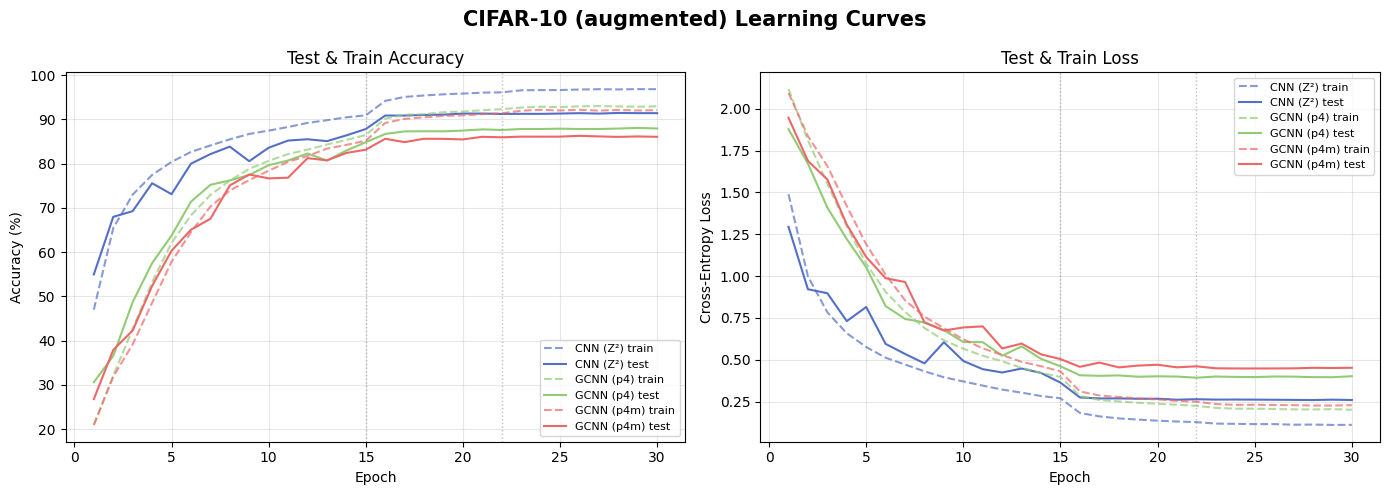

Saved: learning_curves.png


In [12]:
# ── 9.1 Learning Curves ──────────────────────────────────────────────────
# Models loaded from checkpoints have empty epoch lists; they are shown
# as a single horizontal line at their evaluated accuracy instead.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
aug_label = ' (augmented)' if USE_AUGMENTATION else ''
fig.suptitle(f'CIFAR-10{aug_label} Learning Curves', fontsize=15, fontweight='bold')

for model_key, hist in all_results.items():
    name  = DISPLAY_NAMES.get(model_key, model_key)
    color = COLORS.get(model_key, None)
    has_curves = len(hist['train_acc']) > 1

    if has_curves:
        epochs = range(1, len(hist['train_acc']) + 1)
        axes[0].plot(epochs, hist['train_acc'], label=f'{name} train', color=color, linestyle='--', alpha=0.7)
        axes[0].plot(epochs, hist['test_acc'],  label=f'{name} test',  color=color, linestyle='-')
        axes[1].plot(epochs, hist['train_loss'], label=f'{name} train', color=color, linestyle='--', alpha=0.7)
        axes[1].plot(epochs, hist['test_loss'],  label=f'{name} test',  color=color, linestyle='-')
    else:
        # Single-point checkpoint result — draw as a dashed horizontal line
        acc  = hist['best_test_acc']
        loss = hist['test_loss'][0] if hist['test_loss'] else None
        axes[0].axhline(acc,  color=color, linestyle=':', linewidth=1.5,
                        label=f'{name} (checkpoint, {acc:.2f}%)')
        if loss is not None:
            axes[1].axhline(loss, color=color, linestyle=':', linewidth=1.5,
                            label=f'{name} (checkpoint)')

for ax, ylabel, title in zip(axes,
                              ['Accuracy (%)', 'Cross-Entropy Loss'],
                              ['Test & Train Accuracy', 'Test & Train Loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ms in LR_MILESTONES:
    for ax in axes:
        ax.axvline(ms, color='grey', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curves.png')


### 9.2 Best Test Accuracy Bar Chart

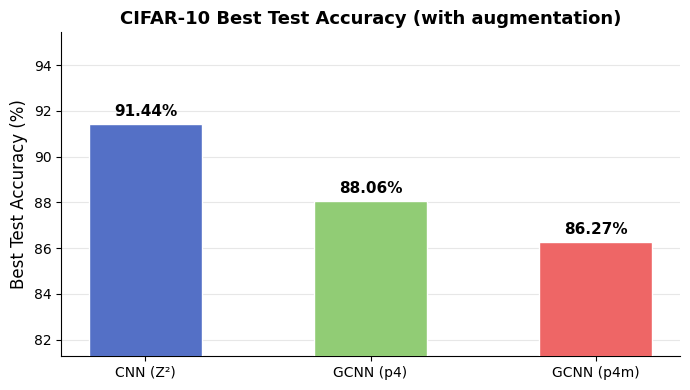

Saved: accuracy_bar.png


In [13]:
keys   = list(all_results.keys())
names  = [DISPLAY_NAMES.get(k, k) for k in keys]
accs   = [all_results[k]['best_test_acc'] for k in keys]
colors = [COLORS.get(k, '#888') for k in keys]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, accs, color=colors, edgecolor='white', width=0.5, zorder=3)

# Annotate bars
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Best Test Accuracy (%)', fontsize=12)
aug_label = ' (with augmentation)' if USE_AUGMENTATION else ' (no augmentation)'
ax.set_title(f'CIFAR-10 Best Test Accuracy{aug_label}', fontsize=13, fontweight='bold')
ax.set_ylim(max(0, min(accs) - 5), min(100, max(accs) + 4))
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: accuracy_bar.png')

### 9.3 Summary Table

In [14]:
print('\n' + '='*70)
print(f'{"Model":<18} {"Parameters":>12} {"Best Test Acc":>14} {"Gain vs CNN":>12}')
print('='*70)

baseline_acc = all_results.get('cnn', {}).get('best_test_acc', None)

for key in all_results:
    hist   = all_results[key]
    acc    = hist['best_test_acc']
    params = hist.get('n_params', '?')
    if baseline_acc is not None and key != 'cnn':
        gain = f'+{acc - baseline_acc:.2f}pp'
    else:
        gain = 'baseline' if key == 'cnn' else '—'
    print(f'{DISPLAY_NAMES.get(key, key):<18} {str(params):>12} {acc:>13.2f}% {gain:>12}')

print('='*70)

if len(all_results) >= 2:
    best_key = max(all_results, key=lambda k: all_results[k]['best_test_acc'])
    print(f'\n→ Best model: {DISPLAY_NAMES.get(best_key, best_key)} '
          f'with {all_results[best_key]["best_test_acc"]:.2f}% accuracy')
    if baseline_acc:
        improvement = all_results[best_key]['best_test_acc'] - baseline_acc
        print(f'→ Improvement over CNN baseline: +{improvement:.2f} percentage points')


Model                Parameters  Best Test Acc  Gain vs CNN
CNN (Z²)                1372254         91.44%     baseline
GCNN (p4)                926304         88.06%     +-3.38pp
GCNN (p4m)               824896         86.27%     +-5.17pp

→ Best model: CNN (Z²) with 91.44% accuracy
→ Improvement over CNN baseline: +0.00 percentage points


## 10. First-Layer Filter Heatmaps

Visualize what each trained model learned in its first layer. GCNN filters should show more structured, rotation-aware patterns compared to the plain CNN.

In [15]:
import math as _math

def first_standard_conv(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            return module
    raise ValueError('No Conv2d layer found.')

def first_group_conv(model):
    for module in model.modules():
        if module.__class__.__name__ == 'R2Conv':
            return module
    raise ValueError('No R2Conv layer found.')

def extract_filters(model, model_key):
    if model_key == 'cnn':
        w = first_standard_conv(model).weight.detach().cpu()
    else:
        gc = first_group_conv(model)
        if hasattr(gc, 'expand_parameters'):
            w, _ = gc.expand_parameters()
        elif hasattr(gc, 'filter'):
            w = gc.filter
        else:
            raise ValueError('Cannot extract filters from R2Conv.')
        w = w.detach().cpu()
    return w

def plot_filter_grid(heatmaps, title, max_filters=24, cmap='mako'):
    count = min(max_filters, heatmaps.shape[0])
    cols  = 6
    rows  = _math.ceil(count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 2.1 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    vmin = float(heatmaps[:count].min())
    vmax = float(heatmaps[:count].max())
    for idx, ax in enumerate(axes):
        if idx < count:
            sns.heatmap(heatmaps[idx], ax=ax, cmap=cmap, cbar=False,
                        square=True, xticklabels=False, yticklabels=False,
                        vmin=vmin, vmax=vmax)
            ax.set_title(f'F{idx}', fontsize=8)
        else:
            ax.axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.savefig(EXPERIMENT_DIR / f'filters_{title.split()[0].lower()}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

print('Filter visualization utilities defined.')

Filter visualization utilities defined.


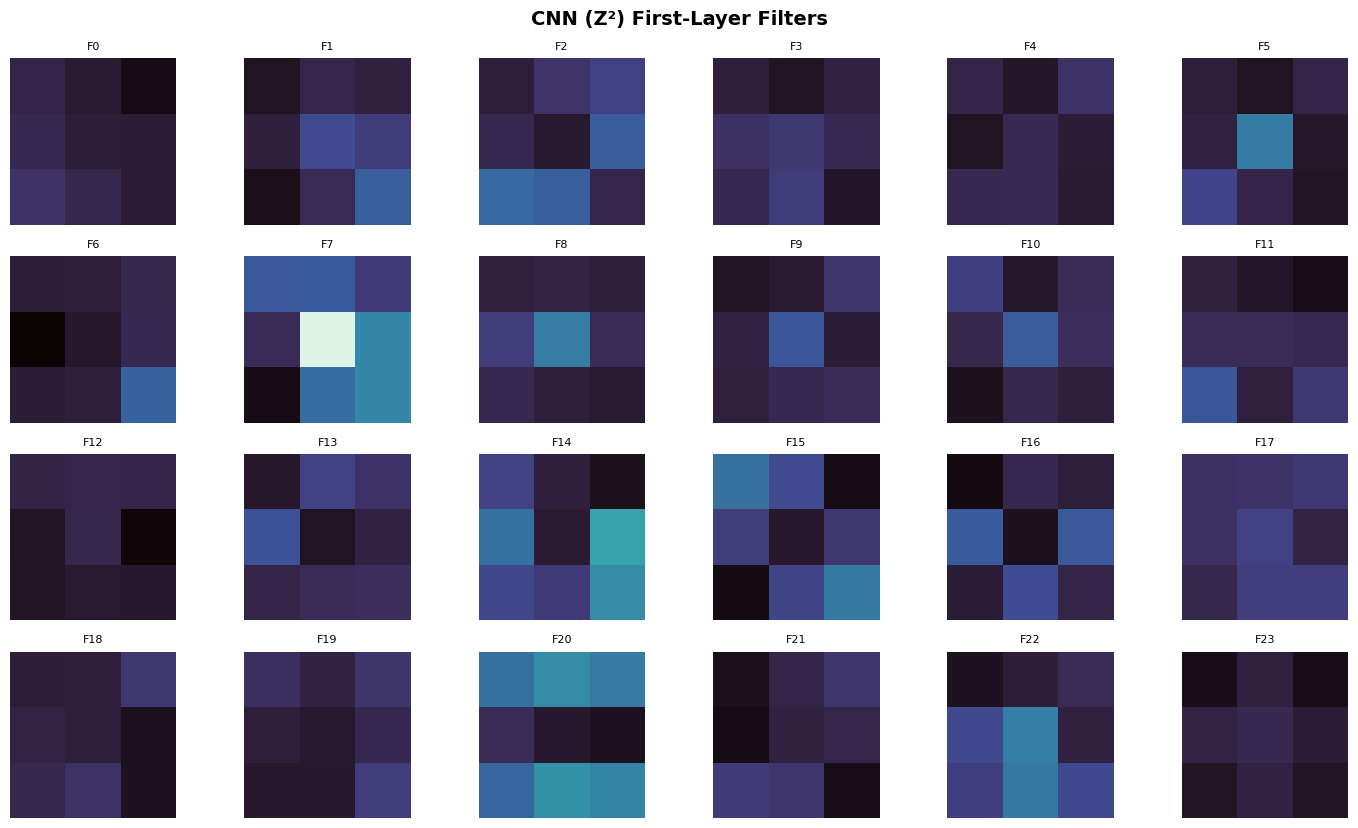

Could not plot filters for gcnn_p4: Expected all tensors to be on the same device, but got mat2 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_bmm)
Could not plot filters for gcnn_p4m: Expected all tensors to be on the same device, but got mat2 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_bmm)


In [16]:
for model_key in all_results:
    ckpt_path = EXPERIMENT_DIR / f'{model_key}.pth'
    if not ckpt_path.exists():
        print(f'No checkpoint for {model_key}, skipping filter plot.')
        continue
    try:
        model = build_model(model_key)
        model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
        model.eval()
        weights  = extract_filters(model, model_key)
        heatmaps = weights.abs().mean(dim=1)   # mean over input channels
        plot_filter_grid(heatmaps,
                         f"{DISPLAY_NAMES[model_key]} First-Layer Filters",
                         max_filters=24)
    except Exception as e:
        print(f'Could not plot filters for {model_key}: {e}')

## 11. Error Rate vs Epoch (Paper-Style)

Plots **test error rate** (100 - accuracy) to match the presentation in the Cohen & Welling (2016) paper.

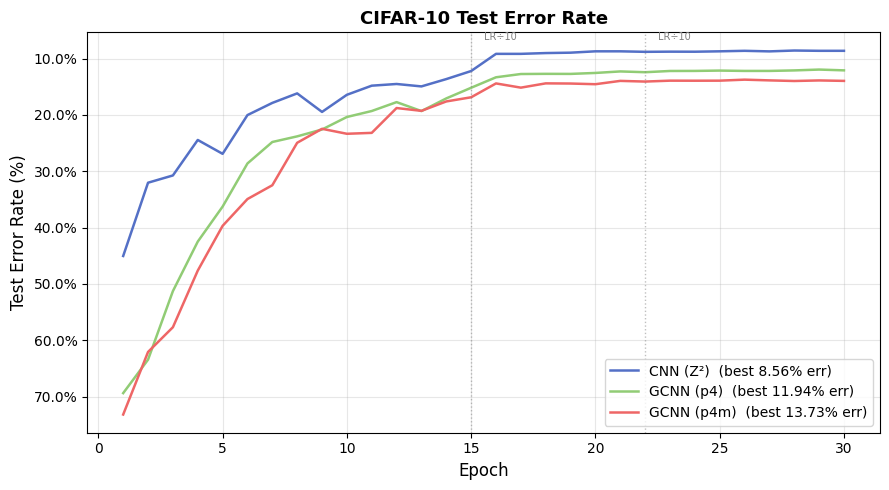

Saved: error_rate.png


In [17]:
# ── 11. Error Rate vs Epoch (Paper-Style) ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for model_key, hist in all_results.items():
    name   = DISPLAY_NAMES.get(model_key, model_key)
    color  = COLORS.get(model_key, None)
    best_err = 100.0 - hist['best_test_acc']

    if len(hist['test_acc']) > 1:
        epochs = range(1, len(hist['test_acc']) + 1)
        error  = [100.0 - a for a in hist['test_acc']]
        ax.plot(epochs, error,
                label=f'{name}  (best {best_err:.2f}% err)',
                color=color, linewidth=1.8)
    else:
        # Checkpoint-only: horizontal line
        ax.axhline(best_err, color=color, linestyle=':', linewidth=1.8,
                   label=f'{name}  (checkpoint, {best_err:.2f}% err)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Error Rate (%)', fontsize=12)
ax.set_title('CIFAR-10 Test Error Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

for ms in LR_MILESTONES:
    ax.axvline(ms, color='grey', linestyle=':', alpha=0.5, linewidth=1)
    ax.text(ms + 0.5, ax.get_ylim()[1], f'LR\u00f710', fontsize=7, color='grey', va='top')

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'error_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_rate.png')


## 12. Interpretation Guide

### What to expect from the results

According to Cohen & Welling (2016), with equal parameters:

| Model | CIFAR-10 (plain) | CIFAR-10 (augmented) |
|-------|-----------------|---------------------|
| CNN (Z²) | ~9.4% error | ~8.9% error |
| GCNN-p4 | ~8.8% error | ~7.7% error |
| GCNN-p4m | ~7.6% error | ~7.0% error |

### Why GCNNs win with the same parameter budget

1. **Weight sharing across orientations** — a single filter in p4 is reused across 4 rotations (p4m: 8), so the network sees each pattern in every orientation during training without needing separate weights.

2. **Equivariant feature maps** — rotating the input rotates the feature maps predictably (eq. 12 in the paper), so later layers can exploit spatial relationships across orientations.

3. **No free lunch on truly rotation-invariant data** — CIFAR-10 objects appear mostly upright, so the gain is real but moderate. On `MNIST-rot` (randomly rotated digits), the improvement is dramatic: CNN ~5% error vs P4CNN ~2.3%.

### Filter heatmap interpretation

- **CNN filters** tend to look like arbitrary edge/texture detectors.
- **GCNN (p4/p4m) filters** are constrained by the group structure, so you often see more organized, symmetric patterns — the network can't learn a rotation-asymmetric filter separately because it already has that covered by weight sharing.

## 13. (Optional) Per-Class Accuracy

Breaks down which CIFAR-10 classes each model struggles with most.

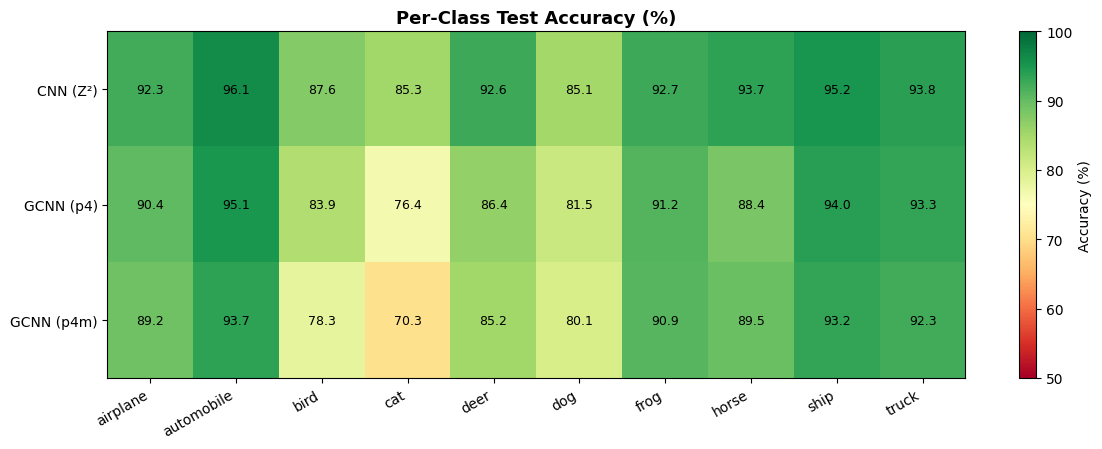

Saved: per_class_accuracy.png


In [18]:
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

@torch.no_grad()
def per_class_accuracy(model, loader, device):
    model.eval()
    correct = [0] * 10
    total   = [0] * 10
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        _, predicted = model(inputs).max(1)
        for t, p in zip(targets.cpu(), predicted.cpu()):
            total[t]   += 1
            correct[t] += int(t == p)
    return [100.0 * c / t if t > 0 else 0 for c, t in zip(correct, total)]

per_class_results = {}

for model_key in all_results:
    ckpt_path = EXPERIMENT_DIR / f'{model_key}.pth'
    if not ckpt_path.exists():
        continue
    try:
        model = build_model(model_key).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        per_class_results[model_key] = per_class_accuracy(model, test_loader, DEVICE)
        del model
    except Exception as e:
        print(f'Per-class eval failed for {model_key}: {e}')

# Plot heatmap of per-class accuracies
if per_class_results:
    matrix = np.array([per_class_results[k] for k in per_class_results])
    row_labels = [DISPLAY_NAMES.get(k, k) for k in per_class_results]

    fig, ax = plt.subplots(figsize=(12, len(row_labels) * 1.2 + 1))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=50, vmax=100, aspect='auto')
    ax.set_xticks(range(10))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=30, ha='right')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_title('Per-Class Test Accuracy (%)', fontsize=13, fontweight='bold')

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i, j]:.1f}', ha='center', va='center',
                    fontsize=9, color='black')

    plt.colorbar(im, ax=ax, label='Accuracy (%)')
    plt.tight_layout()
    plt.savefig(EXPERIMENT_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: per_class_accuracy.png')